In [1]:
!pip install -q easyocr opencv-python-headless

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 43.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 22.9 MB/s eta 0:00:00


In [2]:
import cv2
import easyocr
import matplotlib.pyplot as plt
import numpy as np

In [3]:
image_path = "/content/car.jpg"

In [4]:
image = cv2.imread(image_path)

In [5]:
image

array([[[107, 127, 145],
        [106, 126, 144],
        [105, 125, 143],
        ...,
        [182, 166, 149],
        [182, 166, 149],
        [182, 166, 149]],

       [[108, 128, 146],
        [107, 127, 145],
        [107, 127, 145],
        ...,
        [182, 166, 149],
        [182, 166, 149],
        [182, 166, 149]],

       [[109, 129, 147],
        [109, 129, 147],
        [108, 128, 146],
        ...,
        [182, 166, 149],
        [182, 166, 149],
        [182, 166, 149]],

       ...,

       [[124, 136, 142],
        [154, 166, 172],
        [177, 189, 195],
        ...,
        [ 93,  95,  96],
        [112, 114, 115],
        [128, 130, 131]],

       [[115, 129, 135],
        [147, 161, 167],
        [165, 176, 184],
        ...,
        [ 88,  90,  91],
        [106, 108, 109],
        [121, 123, 124]],

       [[109, 123, 129],
        [125, 139, 145],
        [131, 142, 150],
        ...,
        [ 79,  81,  82],
        [ 82,  84,  85],
        [ 86,  88,  89]]

In [6]:
image = cv2.resize(image, None, fx=0.7, fy=0.7)

array([[[107, 127, 145],
        [106, 125, 144],
        [105, 126, 143],
        ...,
        [182, 166, 149],
        [182, 166, 149],
        [182, 166, 149]],

       [[108, 128, 147],
        [108, 128, 146],
        [108, 128, 146],
        ...,
        [182, 166, 149],
        [182, 166, 149],
        [182, 166, 149]],

       [[110, 130, 148],
        [110, 130, 148],
        [109, 129, 147],
        ...,
        [182, 166, 149],
        [182, 166, 149],
        [182, 166, 149]],

       ...,

       [[128, 140, 144],
        [125, 137, 143],
        [149, 161, 167],
        ...,
        [113, 115, 116],
        [ 97,  99, 100],
        [ 92,  94,  95]],

       [[131, 143, 149],
        [165, 177, 183],
        [160, 172, 178],
        ...,
        [110, 112, 113],
        [ 96,  98,  99],
        [114, 116, 117]],

       [[120, 134, 140],
        [152, 164, 172],
        [129, 140, 148],
        ...,
        [101, 102, 104],
        [ 91,  93,  94],
        [111, 113, 114]]], dtype=uint8)
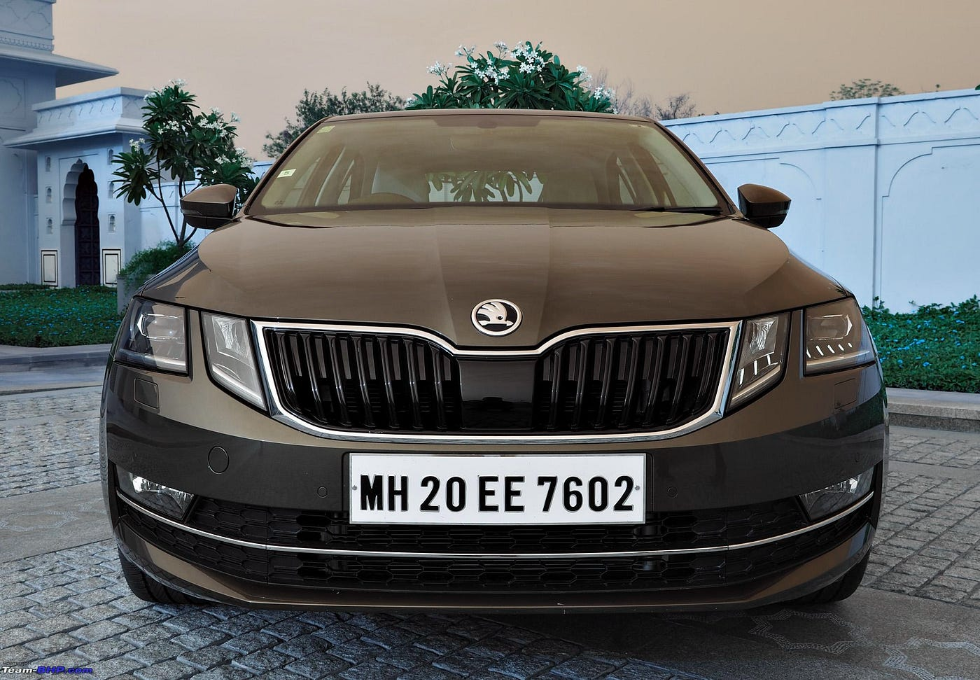

In [7]:
image

In [8]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

array([[130, 129, 129, ..., 163, 163, 163],
       [131, 131, 131, ..., 163, 163, 163],
       [133, 133, 132, ..., 163, 163, 163],
       ...,
       [140, 137, 161, ..., 115,  99,  94],
       [143, 177, 172, ..., 112,  98, 116],
       [134, 165, 141, ..., 102,  93, 113]], dtype=uint8)
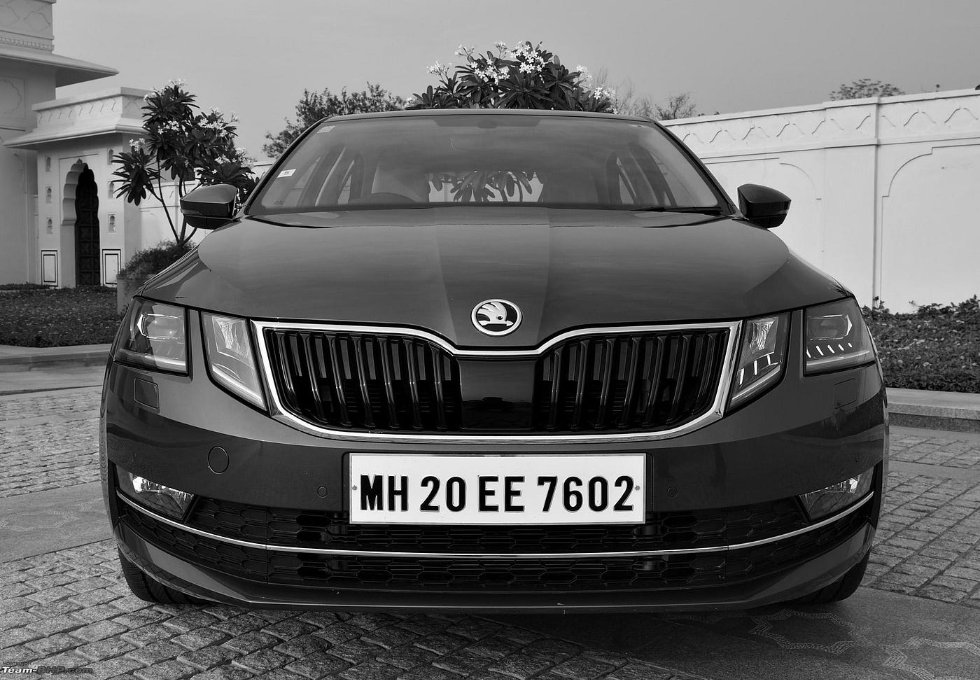

In [9]:
gray

In [10]:
gray = cv2.bilateralFilter(gray, 11, 17, 17)

array([[131, 131, 131, ..., 163, 163, 163],
       [131, 131, 131, ..., 163, 163, 163],
       [131, 131, 131, ..., 163, 163, 163],
       ...,
       [142, 140, 157, ..., 109, 104, 103],
       [144, 168, 165, ..., 108, 105, 110],
       [137, 159, 141, ..., 105, 103, 109]], dtype=uint8)
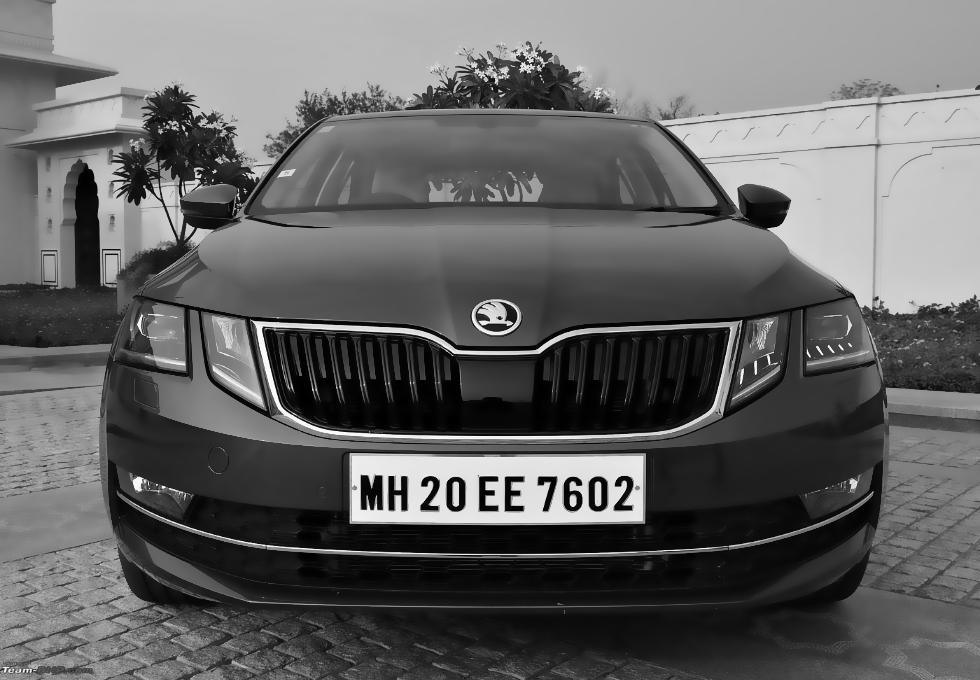

In [11]:
gray

In [12]:
edges = cv2.Canny(gray, 30, 200)

array([[  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       ...,
       [  0, 255, 255, ...,   0,   0,   0],
       [  0, 255,   0, ...,   0,   0,   0],
       [255, 255, 255, ...,   0,   0,   0]], dtype=uint8)
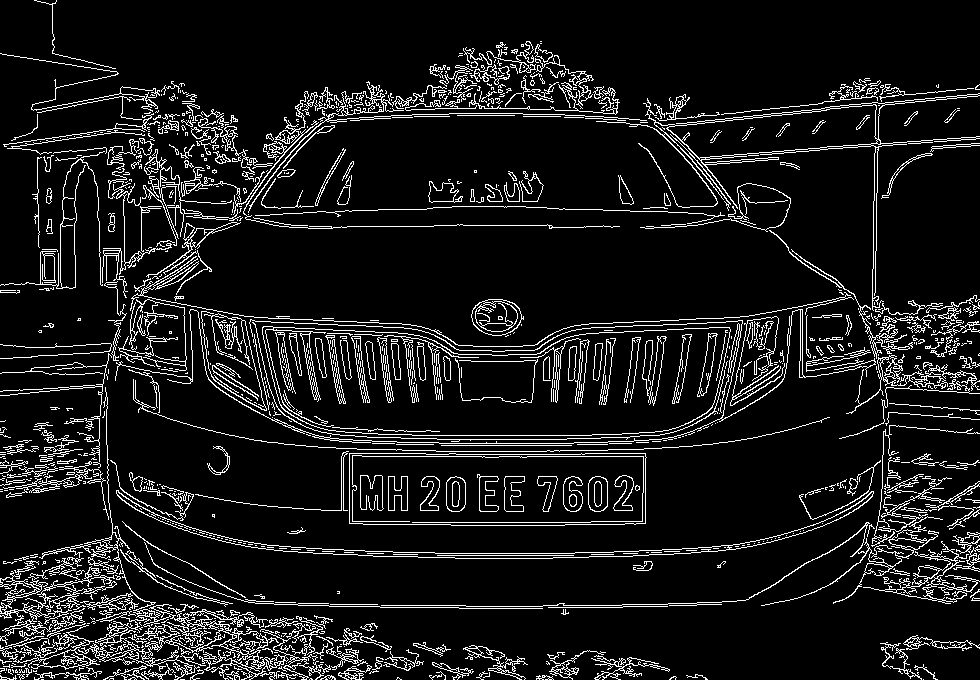

In [13]:
edges

In [14]:
# Find contours
contours, _ = cv2.findContours(
    edges.copy(),
    cv2.RETR_TREE,
    cv2.CHAIN_APPROX_SIMPLE
)


In [15]:
contours

(array([[[923, 679]]], dtype=int32),
 array([[[180, 679]],
 
        [[184, 679]]], dtype=int32),
 array([[[ 41, 679]],
 
        [[ 43, 679]]], dtype=int32),
 array([[[310, 678]],
 
        [[309, 679]],
 
        [[310, 678]],
 
        [[311, 679]],
 
        [[312, 679]],
 
        [[311, 678]]], dtype=int32),
 array([[[110, 678]],
 
        [[109, 679]],
 
        [[110, 678]],
 
        [[112, 678]],
 
        [[113, 679]],
 
        [[113, 678]]], dtype=int32),
 array([[[397, 677]],
 
        [[397, 678]],
 
        [[396, 679]],
 
        [[398, 677]],
 
        [[400, 679]],
 
        [[401, 679]],
 
        [[400, 679]],
 
        [[398, 677]]], dtype=int32),
 array([[[289, 677]],
 
        [[290, 677]],
 
        [[291, 678]],
 
        [[294, 678]],
 
        [[295, 677]],
 
        [[294, 678]],
 
        [[291, 678]],
 
        [[290, 677]]], dtype=int32),
 array([[[132, 677]],
 
        [[131, 678]],
 
        [[130, 678]],
 
        [[129, 679]],
 
        [[128, 679]],

In [16]:
# Keep the largest contours
contours = sorted(
    contours,
    key=cv2.contourArea,
    reverse=True
)[:30]




In [17]:
contours

[array([[[263, 326]],
 
        [[262, 327]],
 
        [[262, 334]],
 
        [[263, 335]],
 
        [[263, 339]],
 
        [[264, 340]],
 
        [[264, 343]],
 
        [[265, 344]],
 
        [[265, 348]],
 
        [[266, 349]],
 
        [[266, 352]],
 
        [[267, 353]],
 
        [[267, 357]],
 
        [[268, 358]],
 
        [[268, 361]],
 
        [[269, 362]],
 
        [[269, 366]],
 
        [[270, 367]],
 
        [[270, 369]],
 
        [[271, 370]],
 
        [[271, 374]],
 
        [[272, 375]],
 
        [[272, 378]],
 
        [[273, 379]],
 
        [[273, 381]],
 
        [[274, 382]],
 
        [[274, 386]],
 
        [[275, 387]],
 
        [[275, 389]],
 
        [[276, 390]],
 
        [[276, 393]],
 
        [[277, 394]],
 
        [[277, 396]],
 
        [[278, 397]],
 
        [[278, 400]],
 
        [[279, 401]],
 
        [[279, 403]],
 
        [[280, 404]],
 
        [[280, 405]],
 
        [[281, 406]],
 
        [[281, 407]],
 
        [[285, 4

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Detected licence plate: MH 20 EE 7602


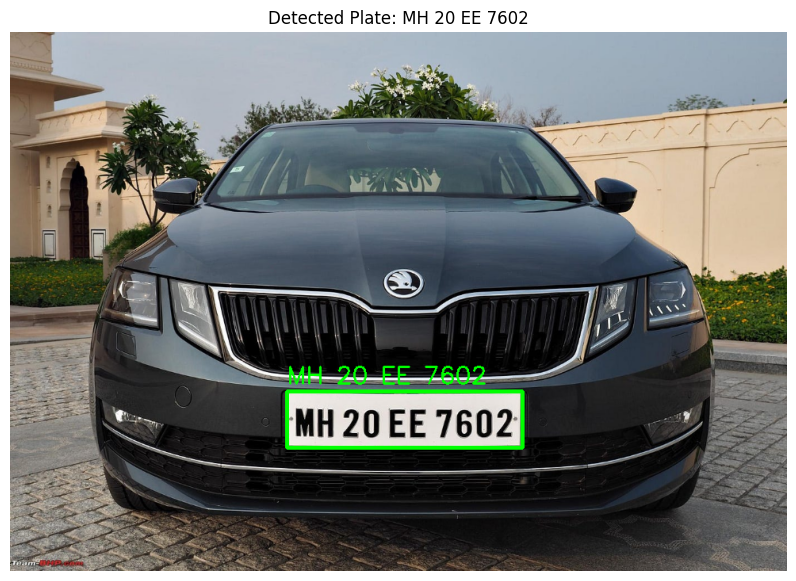

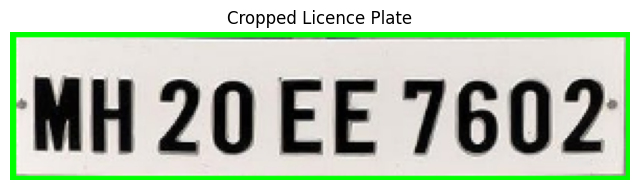

In [18]:
plate_contour = None

# Search for a rectangular contour
for contour in contours:

    perimeter = cv2.arcLength(
        contour,
        True
    )

    approximate_shape = cv2.approxPolyDP(
        contour,
        0.02 * perimeter,
        True
    )

    # Licence plates are usually rectangular
    if len(approximate_shape) == 4:
        plate_contour = approximate_shape
        break


if plate_contour is None:
    print("Licence plate was not detected.")

else:
    # Get plate position
    x, y, width, height = cv2.boundingRect(
        plate_contour
    )

    # Crop licence plate
    plate_image = image[
        y:y + height,
        x:x + width
    ]

    # Create EasyOCR reader
    reader = easyocr.Reader(
        ["en"],
        gpu=False
    )

    # Extract text
    results = reader.readtext(
        plate_image,
        detail=0
    )

    plate_number = " ".join(results)

    print("Detected licence plate:", plate_number)


    # Draw plate box
    cv2.rectangle(
        image,
        (x, y),
        (x + width, y + height),
        (0, 255, 0),
        3
    )


    # Draw plate number
    cv2.putText(
        image,
        plate_number,
        (x, max(30, y - 10)),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0, 255, 0),
        2
    )


    # Convert images from BGR to RGB
    result_rgb = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    plate_rgb = cv2.cvtColor(
        plate_image,
        cv2.COLOR_BGR2RGB
    )


    # Display detected result
    plt.figure(figsize=(12, 7))
    plt.imshow(result_rgb)
    plt.axis("off")
    plt.title(f"Detected Plate: {plate_number}")
    plt.show()


    # Display cropped plate
    plt.figure(figsize=(8, 3))
    plt.imshow(plate_rgb)
    plt.axis("off")
    plt.title("Cropped Licence Plate")
    plt.show()